
##  Loading Libraries & Dataset
#

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display  # print() can only print text , for tabular multiple tabular 
                                     # dataframes to print in a single cell we use display()

import warnings 
warnings.filterwarnings('ignore') # as some functions maybe depricated in future versions to ignore the 
                                  # messages of these updates we ignore them}

In [2]:
df = pd.read_csv('../data/heart.csv')
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


#
# 2) Data Cleaning
#

###
### 2.1 - Handling Cholesterol = 0   &   RestingBP = 0 Error
###

- We have roughly 170+ rows where Cholesterol is 0. These are missing values. We have two options
- Option A -->  Drop these rows. We lose 18% of your data. Not ideal with only 918 rows.

- Option B --> Replacing with Column median or Mean of dataframe columns without these missing value
 
- We go with Option B as we can't rmove 172 rows out of just 918

In [3]:
display(df.describe())
display(df['Cholesterol'].value_counts()) 

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

#### Solution :

- We impute/replace those 0 values assuming that no data was collected for that row for that column with average without those rows for both RestingBP and Cholesterol

####

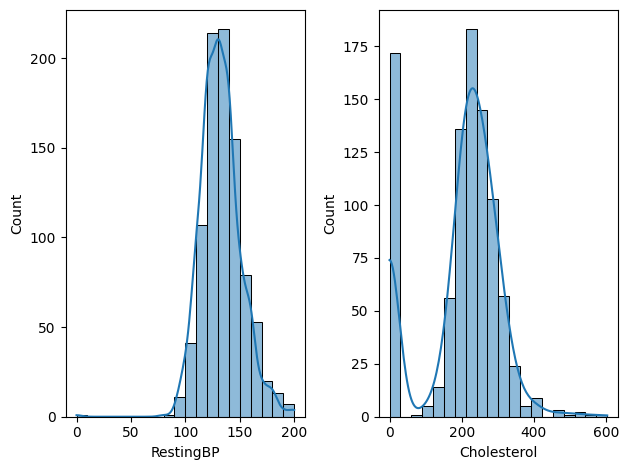

In [4]:
def hist_plot(var , index):
    plt.subplot(1,2,index)
    sns.histplot(df[var],kde=True,bins=20)

hist_plot('RestingBP',1)
hist_plot('Cholesterol',2)
plt.tight_layout()

plt.savefig("../images-recordings/figures/before_imputation.png")

In [5]:
df_without_zero_values_RestingBP = df['RestingBP'] !=0 
df_without_zero_values_RestingBP_mean  = round(df[df_without_zero_values_RestingBP]['RestingBP'].mean(),2)
print(f" RestingBP Mean without 0 values : {df_without_zero_values_RestingBP_mean}")

 RestingBP Mean without 0 values : 132.54


In [6]:
df_without_zero_values_Cholesterol = df['Cholesterol'] !=0 
df_without_zero_values_Cholesterol_mean  = round(df[df_without_zero_values_Cholesterol]['Cholesterol'].mean(),2)
print(f" Cholesterol Mean without 0 values : {df_without_zero_values_Cholesterol_mean}")

 Cholesterol Mean without 0 values : 244.64


In [7]:
df['Cholesterol'] = df['Cholesterol'].replace(0,df_without_zero_values_Cholesterol_mean)
df['RestingBP']   = df['RestingBP'].replace(0,df_without_zero_values_RestingBP_mean)

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
101.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

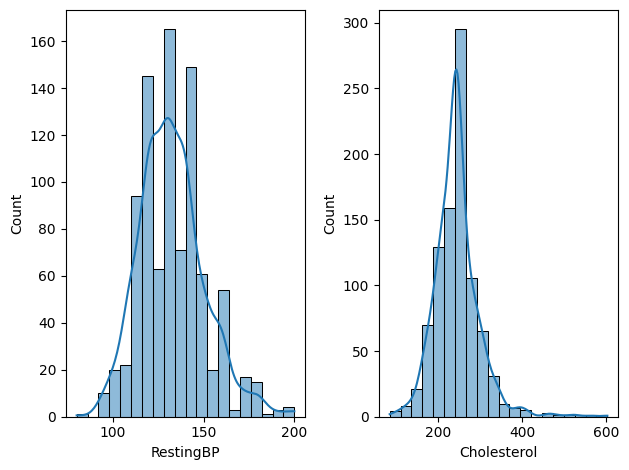

In [13]:
def hist_plot(var , index):
    plt.subplot(1,2,index)
    sns.histplot(df[var],kde=True,bins=20)

hist_plot('RestingBP',1)
hist_plot('Cholesterol',2)
plt.tight_layout()

plt.savefig("../images-recordings/figures/after_imputation.png")

# to verify mean value was replaced or not 
display(df['Cholesterol'].value_counts())
display(df['RestingBP'].value_counts()) 

#### Verification :  Normal Distribution Verified by these histogram plots 

###
### 2.2- Handling Null values 
###

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

- No Null values in any columns ..

###
### 2.3 - Handling Duplicates 
###

In [10]:
df.duplicated().sum()

np.int64(0)

- Duplicates are 0 , No two rows have same entries
- No need of dropping any duplicates

###
### 2.4 - Outlier Handling 
###

In [11]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540893,244.636253,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.989932,53.318029,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.640000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


###
#### Practical Range :

- Age       : Normally distributed with 28,77 (Age should be 20,80: data is normal w.r.t age , no anomalies there)

- RestingBP : (Min,Max) = (80,200) -> Which is practically possible 

- Cholesterol : (85,603) -> Which is practically possible

- MaxHR     : Normally Distributed (60,202) : Normal Range of Heart Rate -> Human limit is 220 BPM


- We dont remove outliers so model learns from them as well if they are practically possible ..

###
### 2.5 - Saving Cleaned Dataset 
###

In [12]:
file_path = '../data/01_cleaned_heart_data.csv'
df.to_csv(file_path , index = False)

# INDEX = false is critical , without this python will save index as a new unnecessary column 